In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


<Axes: xlabel='count', ylabel='Count'>

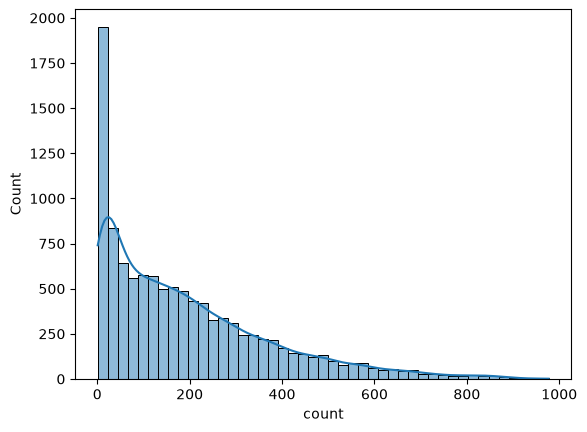

In [8]:
sns.histplot(df['count'],kde = True)

In [12]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [15]:
df['hour'] = df['datetime'].dt.hour

In [16]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


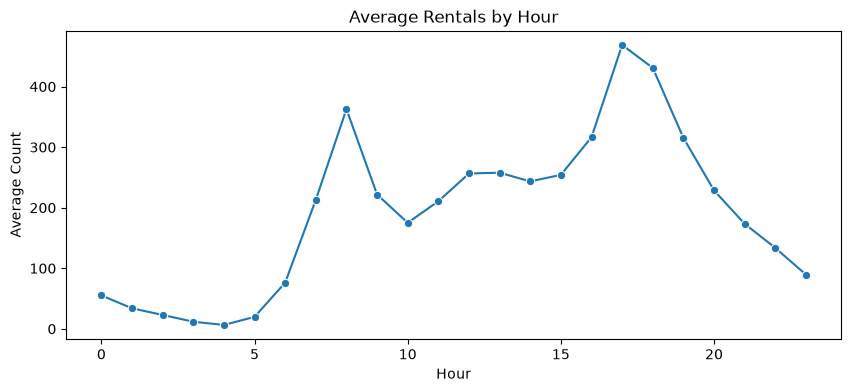

In [20]:
hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.title('Average Rentals by Hour')
plt.show()

In [23]:
df.groupby('season')['count'].count()

season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64

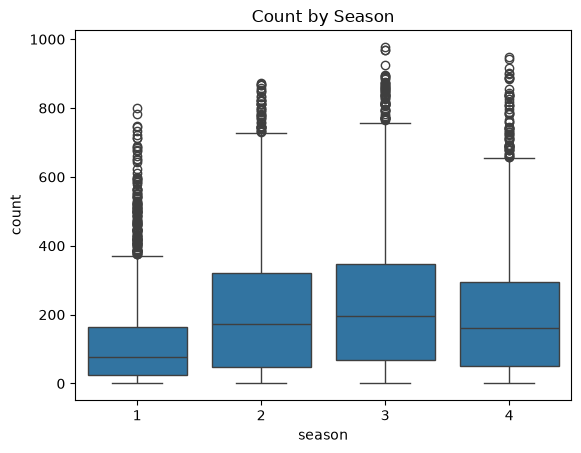

In [27]:
sns.boxplot(data=df, x='season', y='count')
plt.title('Count by Season')
plt.show()

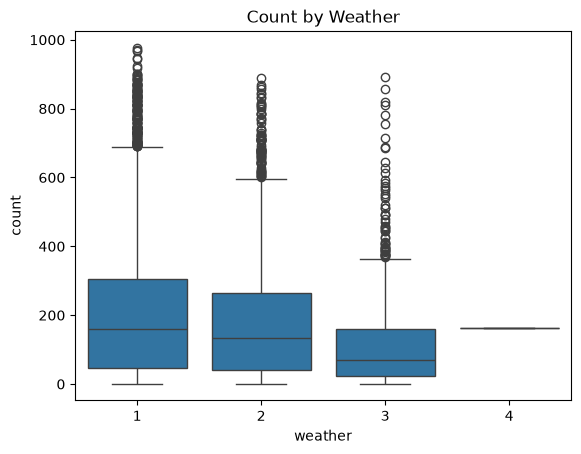

In [28]:
sns.boxplot(data=df, x='weather', y='count')
plt.title('Count by Weather')
plt.show()

In [29]:
df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

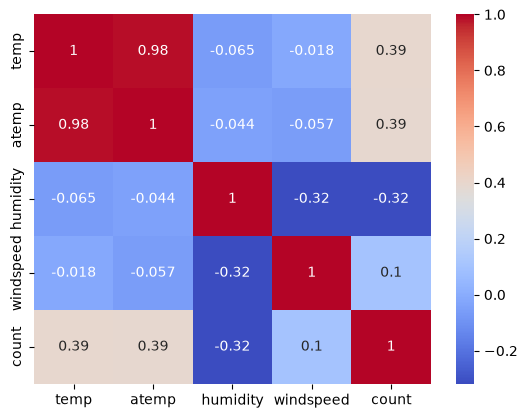

In [30]:
sns.heatmap(df[['temp','atemp','humidity','windspeed','count']].corr(), annot=True, cmap='coolwarm')
plt.show()

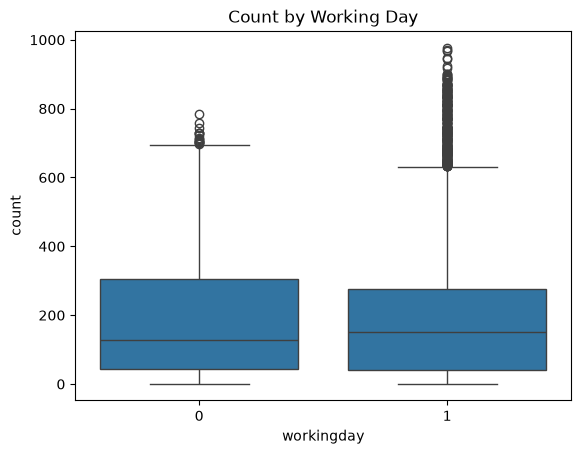

In [31]:
sns.boxplot(data=df, x='workingday', y='count')
plt.title('Count by Working Day')
plt.show()

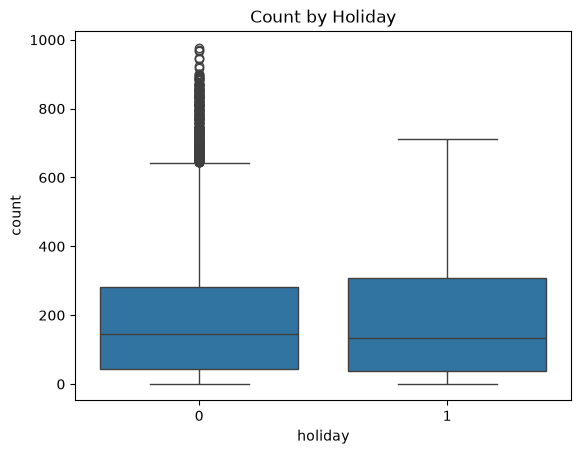

In [32]:
sns.boxplot(data=df, x='holiday', y='count')
plt.title('Count by Holiday')
plt.show()

In [33]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['weekday'] = df['datetime'].dt.weekday

In [34]:
# Cyclical encode hour (so hour 23 and hour 0 are treated as close, not far apart)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [35]:
df['weather'] = df['weather'].replace(4, 3)

In [36]:
df = df.drop(['datetime', 'atemp', 'casual', 'registered', 'hour'], axis=1)

In [37]:
df.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,count,month,year,weekday,hour_sin,hour_cos
0,1,0,0,1,9.84,81,0.0,16,1,2011,5,0.000000,1.000000
1,1,0,0,1,9.02,80,0.0,40,1,2011,5,0.258819,0.965926
2,1,0,0,1,9.02,80,0.0,32,1,2011,5,0.500000,0.866025
3,1,0,0,1,9.84,75,0.0,13,1,2011,5,0.707107,0.707107
4,1,0,0,1,9.84,75,0.0,1,1,2011,5,0.866025,0.500000


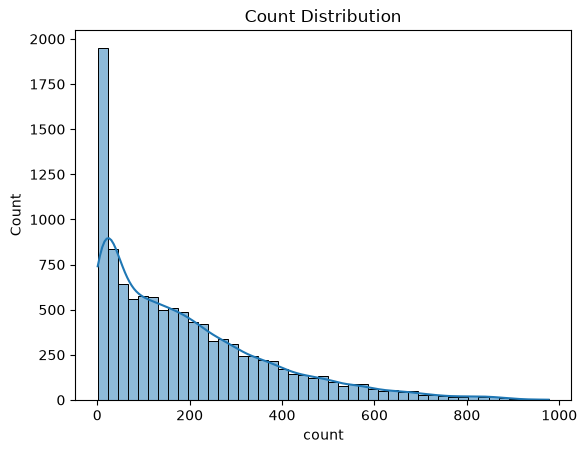

In [42]:
sns.histplot(df['count'], kde=True)
plt.title('Count Distribution')
plt.show()

In [43]:
df['count_log'] = np.log1p(df['count'])

In [45]:
categorical_cols = ['season', 'weather', 'month', 'weekday']
numeric_cols = ['temp', 'humidity', 'windspeed', 'hour_sin', 'hour_cos', 'year']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

In [47]:
split_idx = int(len(df) * 0.8)
split_idx

8708

In [48]:
df.shape

(10886, 14)

In [49]:
X = df.drop(['count', 'count_log'], axis=1)
y = df['count_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [50]:
# Preprocess once
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

def evaluate(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")

In [51]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
evaluate(y_test, lr.predict(X_test_processed))

RMSE: 197.64, MAE: 134.54, R2: 0.175


In [52]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)
evaluate(y_test, ridge.predict(X_test_processed))

RMSE: 197.49, MAE: 134.44, R2: 0.176


In [53]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_processed, y_train)
evaluate(y_test, lasso.predict(X_test_processed))

RMSE: 189.20, MAE: 128.15, R2: 0.244


In [54]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
evaluate(y_test, poly_model.predict(X_test_poly))

RMSE: 172.05, MAE: 111.02, R2: 0.375


In [55]:
svr = SVR(kernel='rbf', C=10)
svr.fit(X_train_processed, y_train)
evaluate(y_test, svr.predict(X_test_processed))

RMSE: 98.78, MAE: 61.84, R2: 0.794


In [74]:
dt = DecisionTreeRegressor(max_depth=20, random_state=42)
dt.fit(X_train_processed, y_train)
evaluate(y_test, dt.predict(X_test_processed))

RMSE: 106.45, MAE: 67.56, R2: 0.761


In [69]:
rf = RandomForestRegressor(n_estimators=220, random_state=42)
rf.fit(X_train_processed, y_train)
evaluate(y_test, rf.predict(X_test_processed))

RMSE: 98.94, MAE: 65.02, R2: 0.793


In [72]:
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_processed, y_train)
evaluate(y_test, xgb_model.predict(X_test_processed))

RMSE: 91.63, MAE: 61.23, R2: 0.823


In [75]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Use time-aware CV instead of default random KFold (matches your split logic)
tscv = TimeSeriesSplit(n_splits=5)

In [76]:
svr_params = {
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2]
}

svr_grid = GridSearchCV(SVR(kernel='rbf'), svr_params, cv=tscv,
                         scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
svr_grid.fit(X_train_processed, y_train)

print("Best SVR params:", svr_grid.best_params_)
evaluate(y_test, svr_grid.best_estimator_.predict(X_test_processed))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best SVR params: {'C': 10, 'epsilon': 0.2, 'gamma': 0.1}
RMSE: 95.27, MAE: 60.59, R2: 0.808


In [77]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=tscv,
                        scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_processed, y_train)

print("Best RF params:", rf_grid.best_params_)
evaluate(y_test, rf_grid.best_estimator_.predict(X_test_processed))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best RF params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
RMSE: 98.83, MAE: 65.20, R2: 0.794


In [79]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=tscv,
                         scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_processed, y_train)

print("Best XGB params:", xgb_grid.best_params_)
evaluate(y_test, xgb_grid.best_estimator_.predict(X_test_processed))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
RMSE: 86.89, MAE: 55.31, R2: 0.841


In [81]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42
    ))
])

In [84]:
# Fit on full X, y (not just train) for the final deployed model
X_full = df.drop(['count', 'count_log'], axis=1)
y_full = df['count_log']

final_pipeline.fit(X_full, y_full)

joblib.dump(final_pipeline, 'bike_demand_model.pkl')

['bike_demand_model.pkl']